# Sust 2.1: Traductor Español–Quechua con RNN

**Actividad:** Desarrollo de un traductor automático del español al quechua utilizando Redes Neuronales Recurrentes.

Este notebook está preparado para **Google Colab**. No necesita subir un CSV externo porque el corpus educativo está incluido dentro del mismo archivo. Implementa:

- Recopilación de un corpus paralelo español–quechua.
- Preprocesamiento: normalización, tokenización, vocabulario y padding.
- Modelo Seq2Seq con **RNN simple**.
- Modelo Seq2Seq con **LSTM** para comparación.
- Evaluación con **BLEU score**.
- Prueba de traducción con una frase ingresada por el usuario.

> Nota académica: el corpus incluido es pequeño y educativo. Para un traductor real debe ampliarse con corpus validado por hablantes competentes de quechua.

In [1]:
# ============================================================
# 0. Configuración inicial
# ============================================================
import re
import random
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    from torch import nn
    from torch.utils.data import Dataset, DataLoader
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("PyTorch no está instalado. En Google Colab normalmente ya viene instalado. Si falla, ejecuta: !pip install torch") from e

try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Evita lentitud por exceso de hilos en CPU.
torch.set_num_threads(1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", DEVICE)

Dispositivo usado: cuda


## 1. Corpus paralelo español–quechua

Se define un corpus pequeño con pares de frases. En un proyecto real se recomienda usar un corpus paralelo más amplio, revisado por docentes o hablantes de quechua.

In [2]:
pares = [
    ("hola", "rimaykullayki"),
    ("buenos dias", "allin p'unchay"),
    ("buenas tardes", "allin ch'isi"),
    ("buenas noches", "allin tuta"),
    ("gracias", "añay"),
    ("muchas gracias", "anchata añay"),
    ("de nada", "imapas kanchu"),
    ("por favor", "ama hina kaychu"),
    ("como estas", "imaynallan kachkanki"),
    ("estoy bien", "allillanmi kani"),
    ("yo estoy bien", "ñuqa allillanmi kani"),
    ("cual es tu nombre", "ima sutiyki"),
    ("mi nombre es juan", "sutiy juan"),
    ("mi nombre es maria", "sutiy maria"),
    ("yo soy estudiante", "ñuqa yachakuq kani"),
    ("tu eres profesor", "qam yachachiq kanki"),
    ("ella es profesora", "pay yachachiqmi"),
    ("el es estudiante", "pay yachakuqmi"),
    ("nosotros somos estudiantes", "ñuqanchik yachakuqkuna kanchik"),
    ("quiero agua", "yaku munani"),
    ("quiero pan", "tanta munani"),
    ("quiero comida", "mikhuna munani"),
    ("necesito ayuda", "yanapayta munani"),
    ("donde esta la escuela", "maypin yachay wasi kachkan"),
    ("la escuela es grande", "yachay wasi hatunmi"),
    ("la casa es pequeña", "wasi uchuymi"),
    ("el agua es fria", "yaku chirim"),
    ("el sol es fuerte", "inti kallpawanmi"),
    ("la luna es bonita", "killa sumaqmi"),
    ("voy a la escuela", "yachay wasiman rini"),
    ("voy a mi casa", "wasiyta rini"),
    ("ven aqui", "hamuy kayman"),
    ("vamos juntos", "kuska risunchik"),
    ("abre la puerta", "punkuta kichay"),
    ("cierra la puerta", "punkuta wichqay"),
    ("lee el libro", "qillqa maytuta ñawinchay"),
    ("escribe tu nombre", "sutiykita qillqay"),
    ("escucha al profesor", "yachachiqta uyariy"),
    ("mira la pizarra", "qillqana pirqata qaway"),
    ("hoy aprendemos quechua", "kunan runasimita yachakunchik"),
    ("mañana estudiaremos", "paqarin yachasaqku"),
    ("ayer fuimos al mercado", "qayna punchaw qhatuman rirqanchik"),
    ("el niño juega", "wawa pukllan"),
    ("la niña canta", "warmi wawa takin"),
    ("el perro corre", "allqu phawan"),
    ("el gato duerme", "misi puñun"),
    ("la madre cocina", "mama waykuchkan"),
    ("el padre trabaja", "tayta llamkachkan"),
    ("mi familia vive en cusco", "aylluy qusqopi tiyan"),
    ("yo vivo en cusco", "ñuqa qusqopi tiyani"),
    ("la comunidad es importante", "aylluqa ancha chaninniyuqmi"),
    ("respetamos nuestra cultura", "kawsayninchikta yupaychanchik"),
    ("aprendemos con responsabilidad", "kamachikuyniyuqta yachakunchik"),
    ("el proyecto usa redes neuronales", "llamkayqa yuyay llikakunata llamkachin"),
    ("la computadora procesa datos", "antañiqiq willakuykunata rurachin"),
    ("los datos son importantes", "willakuykuna ancha chaninniyuqmi"),
    ("el modelo aprende patrones", "modeloqa rikchaykunata yachakun"),
    ("la traduccion automatica ayuda", "kikin tikrayqa yanapan"),
    ("la evaluacion mide resultados", "chaninchayqa ruraykunata tupun"),
    ("la red recurrente procesa secuencias", "kutipaq llikamanta siqikunata rurachin"),
    ("la memoria es limitada", "yuyayqa pisim"),
    ("lstm mejora la memoria", "lstm yuyayta allichan"),
    ("este es un ejemplo educativo", "kayqa yachaypaq rikchaymi"),
    ("buen trabajo", "allin llamkay"),
    ("hasta luego", "tupananchiskama"),
]

def normalizar(texto: str) -> str:
    texto = texto.lower().strip()
    texto = re.sub(r"[^a-záéíóúñü' ]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

pares = [(normalizar(es), normalizar(qu)) for es, qu in pares]
df = pd.DataFrame(pares, columns=["espanol", "quechua"])
print("Tamaño del corpus:", len(df), "pares")
df.head(10)

Tamaño del corpus: 65 pares


,espanol,quechua
0,hola,rimaykullayki
1,buenos dias,allin p'unchay
2,buenas tardes,allin ch'isi
3,buenas noches,allin tuta
4,gracias,añay
5,muchas gracias,anchata añay
6,de nada,imapas kanchu
7,por favor,ama hina kaychu
8,como estas,imaynallan kachkanki
9,estoy bien,allillanmi kani


## 2. División de datos, vocabulario y padding

El modelo necesita convertir palabras en números. Para ello se crean vocabularios de entrada y salida, además de tokens especiales:

- `<pad>`: relleno para igualar longitudes.
- `<sos>`: inicio de frase en el decodificador.
- `<eos>`: final de frase.
- `<unk>`: palabra no reconocida.

In [3]:
# División reproducible entrenamiento/prueba
indices = list(range(len(pares)))
random.shuffle(indices)
tam_prueba = max(6, int(len(indices) * 0.10))
idx_prueba = set(indices[:tam_prueba])
pares_train = [pares[i] for i in indices[tam_prueba:]]
pares_test = [pares[i] for i in indices[:tam_prueba]]

print("Pares de entrenamiento:", len(pares_train))
print("Pares de prueba:", len(pares_test))

SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]
PAD, SOS, EOS, UNK = 0, 1, 2, 3

def construir_vocabulario(textos):
    vocab = {tok: i for i, tok in enumerate(SPECIALS)}
    for texto in textos:
        for tok in texto.split():
            if tok not in vocab:
                vocab[tok] = len(vocab)
    inv = {i: t for t, i in vocab.items()}
    return vocab, inv

# Para esta práctica educativa se usa todo el corpus para el vocabulario,
# evitando que el conjunto de prueba quede excesivamente afectado por <unk>.
vocab_es, inv_es = construir_vocabulario([es for es, _ in pares])
vocab_qu, inv_qu = construir_vocabulario([qu for _, qu in pares])

MAX_SRC = max(len(es.split()) for es, _ in pares) + 1
MAX_TGT = max(len(qu.split()) for _, qu in pares) + 2

print("Vocabulario español:", len(vocab_es))
print("Vocabulario quechua:", len(vocab_qu))
print("Longitud máxima entrada:", MAX_SRC)
print("Longitud máxima salida:", MAX_TGT)

Pares de entrenamiento: 59
Pares de prueba: 6
Vocabulario español: 137
Vocabulario quechua: 133
Longitud máxima entrada: 6
Longitud máxima salida: 6


In [4]:
def codificar_entrada(texto):
    tokens = normalizar(texto).split() + ["<eos>"]
    ids = [vocab_es.get(tok, UNK) for tok in tokens]
    return ids + [PAD] * (MAX_SRC - len(ids))

def codificar_salida_entrada(texto):
    tokens = ["<sos>"] + normalizar(texto).split()
    ids = [vocab_qu.get(tok, UNK) for tok in tokens]
    return ids + [PAD] * (MAX_TGT - len(ids))

def codificar_salida_objetivo(texto):
    tokens = normalizar(texto).split() + ["<eos>"]
    ids = [vocab_qu.get(tok, UNK) for tok in tokens]
    return ids + [PAD] * (MAX_TGT - len(ids))

class DatasetTraduccion(Dataset):
    def __init__(self, pares_datos):
        self.X = torch.tensor([codificar_entrada(es) for es, _ in pares_datos], dtype=torch.long)
        self.Yin = torch.tensor([codificar_salida_entrada(qu) for _, qu in pares_datos], dtype=torch.long)
        self.Yout = torch.tensor([codificar_salida_objetivo(qu) for _, qu in pares_datos], dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Yin[idx], self.Yout[idx]

train_dataset = DatasetTraduccion(pares_train)
test_dataset = DatasetTraduccion(pares_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
print("Ejemplo codificado de entrada:", train_dataset[0][0])
print("Ejemplo codificado de salida:", train_dataset[0][1])

Ejemplo codificado de entrada: tensor([38, 40,  2,  0,  0,  0])
Ejemplo codificado de salida: tensor([ 1, 38, 37,  0,  0,  0])


## 3. Arquitectura Seq2Seq con RNN simple y LSTM

La arquitectura se compone de:

1. **Embedding:** convierte cada token en un vector numérico denso.
2. **Encoder recurrente:** procesa la frase en español.
3. **Decoder recurrente:** genera la frase en quechua.
4. **Capa lineal de salida:** predice la palabra más probable del vocabulario quechua.

Se implementa primero con `RNN` simple y luego con `LSTM` para comparar el comportamiento.

In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, rnn_type="RNN"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.RNN
        self.rnn = rnn_cls(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)
        _, hidden = self.rnn(emb)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, rnn_type="RNN"):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.RNN
        self.rnn = rnn_cls(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt_in, hidden):
        emb = self.embedding(tgt_in)
        salida, hidden = self.rnn(emb, hidden)
        logits = self.fc(salida)
        return logits, hidden

class Seq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, emb_dim=32, hidden_dim=64, rnn_type="RNN"):
        super().__init__()
        self.rnn_type = rnn_type
        self.encoder = Encoder(src_vocab_size, emb_dim, hidden_dim, rnn_type)
        self.decoder = Decoder(tgt_vocab_size, emb_dim, hidden_dim, rnn_type)

    def forward(self, src, tgt_in):
        hidden = self.encoder(src)
        logits, _ = self.decoder(tgt_in, hidden)
        return logits

## 4. Entrenamiento de los modelos

Se entrena un modelo con RNN simple y otro con LSTM. La función de pérdida es entropía cruzada, ignorando el token de padding.

In [6]:
def entrenar_modelo(rnn_type="RNN", epochs=150, lr=0.01):
    modelo = Seq2Seq(
        src_vocab_size=len(vocab_es),
        tgt_vocab_size=len(vocab_qu),
        emb_dim=32,
        hidden_dim=64,
        rnn_type=rnn_type
    ).to(DEVICE)

    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.CrossEntropyLoss(ignore_index=PAD)
    historial = []

    for epoch in range(1, epochs + 1):
        modelo.train()
        perdida_total = 0.0

        for src, yin, yout in train_loader:
            src = src.to(DEVICE)
            yin = yin.to(DEVICE)
            yout = yout.to(DEVICE)

            optimizador.zero_grad()
            logits = modelo(src, yin)
            loss = criterio(logits.reshape(-1, logits.size(-1)), yout.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizador.step()

            perdida_total += loss.item()

        perdida_promedio = perdida_total / len(train_loader)
        historial.append(perdida_promedio)

        if epoch == 1 or epoch % 30 == 0:
            print(f"{rnn_type} | Época {epoch:03d}/{epochs} | Pérdida: {perdida_promedio:.4f}")

    return modelo, historial

modelo_rnn, perdida_rnn = entrenar_modelo("RNN", epochs=150, lr=0.01)
modelo_lstm, perdida_lstm = entrenar_modelo("LSTM", epochs=150, lr=0.01)

RNN | Época 001/150 | Pérdida: 4.8363
RNN | Época 030/150 | Pérdida: 0.2451
RNN | Época 060/150 | Pérdida: 0.0345
RNN | Época 090/150 | Pérdida: 0.0115
RNN | Época 120/150 | Pérdida: 0.0062
RNN | Época 150/150 | Pérdida: 0.0040
LSTM | Época 001/150 | Pérdida: 4.8451
LSTM | Época 030/150 | Pérdida: 0.0507
LSTM | Época 060/150 | Pérdida: 0.0091
LSTM | Época 090/150 | Pérdida: 0.0043
LSTM | Época 120/150 | Pérdida: 0.0026
LSTM | Época 150/150 | Pérdida: 0.0018


## 5. Curvas de pérdida

La pérdida permite observar si el modelo está aprendiendo durante el entrenamiento.

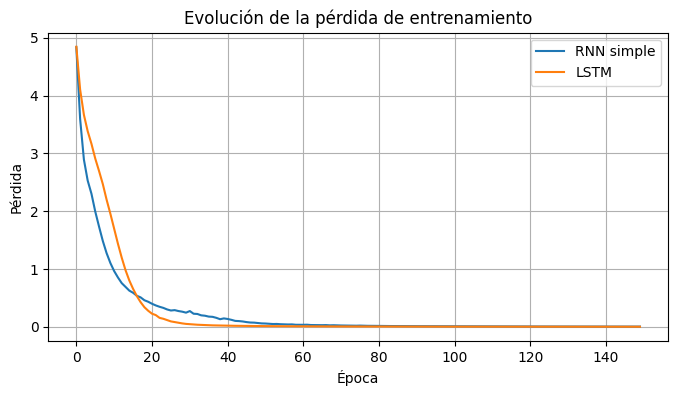

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(perdida_rnn, label="RNN simple")
plt.plot(perdida_lstm, label="LSTM")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida de entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

## 6. Función de traducción

La traducción se genera palabra por palabra con decodificación greedy, seleccionando el token más probable en cada paso.

In [8]:
@torch.no_grad()
def traducir(modelo, frase, max_len=MAX_TGT):
    modelo.eval()
    frase = normalizar(frase)
    src = torch.tensor([codificar_entrada(frase)], dtype=torch.long).to(DEVICE)
    hidden = modelo.encoder(src)

    token_actual = torch.tensor([[SOS]], dtype=torch.long).to(DEVICE)
    tokens_salida = []

    for _ in range(max_len):
        logits, hidden = modelo.decoder(token_actual, hidden)
        pred_id = int(logits[:, -1, :].argmax(dim=-1).item())

        if pred_id in [EOS, PAD]:
            break

        tokens_salida.append(inv_qu.get(pred_id, "<unk>"))
        token_actual = torch.tensor([[pred_id]], dtype=torch.long).to(DEVICE)

    return " ".join(tokens_salida)

frases_demo = ["hola", "gracias", "quiero agua", "yo soy estudiante", "hasta luego"]
for frase in frases_demo:
    print("Español:", frase)
    print("RNN   :", traducir(modelo_rnn, frase))
    print("LSTM  :", traducir(modelo_lstm, frase))
    print("-" * 45)

Español: hola
RNN   : rimaykullayki
LSTM  : rimaykullayki
---------------------------------------------
Español: gracias
RNN   : añay
LSTM  : añay
---------------------------------------------
Español: quiero agua
RNN   : yaku munani
LSTM  : yaku munani
---------------------------------------------
Español: yo soy estudiante
RNN   : ñuqa yachakuq kani
LSTM  : ñuqa yachakuq kani
---------------------------------------------
Español: hasta luego
RNN   : tupananchiskama
LSTM  : tupananchiskama
---------------------------------------------


## 7. Evaluación con BLEU score

BLEU compara la traducción generada con la traducción de referencia. En corpus pequeños, el valor suele ser bajo porque el modelo tiene pocos ejemplos para generalizar.

In [9]:
smooth = SmoothingFunction().method1

def evaluar_bleu(modelo, pares_eval):
    referencias = []
    hipotesis = []
    filas = []

    for es, qu_ref in pares_eval:
        pred = traducir(modelo, es)
        referencias.append([qu_ref.split()])
        hipotesis.append(pred.split())
        filas.append({
            "español": es,
            "referencia_quechua": qu_ref,
            "prediccion": pred
        })

    bleu = corpus_bleu(referencias, hipotesis, smoothing_function=smooth)
    return bleu, pd.DataFrame(filas)

bleu_rnn_test, tabla_rnn_test = evaluar_bleu(modelo_rnn, pares_test)
bleu_lstm_test, tabla_lstm_test = evaluar_bleu(modelo_lstm, pares_test)

print(f"BLEU prueba - RNN simple: {bleu_rnn_test:.4f}")
print(f"BLEU prueba - LSTM      : {bleu_lstm_test:.4f}")

resultados = pd.DataFrame({
    "Modelo": ["RNN simple", "LSTM"],
    "BLEU prueba": [bleu_rnn_test, bleu_lstm_test],
    "Pérdida final": [perdida_rnn[-1], perdida_lstm[-1]]
})
resultados

BLEU prueba - RNN simple: 0.0180
BLEU prueba - LSTM      : 0.0186


,Modelo,BLEU prueba,Pérdida final
0,RNN simple,0.018012,0.004024
1,LSTM,0.018640,0.001803


In [10]:
print("Predicciones del modelo RNN simple sobre el conjunto de prueba:")
tabla_rnn_test

Predicciones del modelo RNN simple sobre el conjunto de prueba:


,español,referencia_quechua,prediccion
0,el perro corre,allqu phawan,pay yachakuqmi
1,los datos son importantes,willakuykuna ancha chaninniyuqmi,inti kallpawanmi
2,por favor,ama hina kaychu,imaynallan kachkanki
3,donde esta la escuela,maypin yachay wasi kachkan,yachay wasiman rini
4,la madre cocina,mama waykuchkan,qillqana pirqata qaway
5,hoy aprendemos quechua,kunan runasimita yachakunchik,punkuta wichqay


In [11]:
print("Predicciones del modelo LSTM sobre el conjunto de prueba:")
tabla_lstm_test

Predicciones del modelo LSTM sobre el conjunto de prueba:


,español,referencia_quechua,prediccion
0,el perro corre,allqu phawan,tayta llamkachkan
1,los datos son importantes,willakuykuna ancha chaninniyuqmi,tayta llamkachkan
2,por favor,ama hina kaychu,imaynallan kachkanki
3,donde esta la escuela,maypin yachay wasi kachkan,yachay wasiman rini
4,la madre cocina,mama waykuchkan,aylluqa ancha chaninniyuqmi
5,hoy aprendemos quechua,kunan runasimita yachakunchik,ñuqa yachakuq kani


## 8. Prueba manual del traductor

Cambia el texto de la variable `frase_usuario` para probar otra frase. El modelo responderá con la predicción en quechua.

In [ ]:
# Prueba interactiva del traductor Español-Quechua

while True:
    frase_usuario = input("Ingrese una frase en español para traducir o escriba 'salir': ").strip().lower()

    if frase_usuario == "salir":
        print("Prueba finalizada.")
        break

    if frase_usuario == "":
        print("Debe ingresar una frase válida.")
        continue

    print("\nFrase en español:", frase_usuario)
    print("Traducción con RNN simple:", traducir(modelo_rnn, frase_usuario))
    print("Traducción con LSTM:", traducir(modelo_lstm, frase_usuario))
    print("-" * 60)

Ingrese una frase en español para traducir o escriba 'salir': hola

Frase en español: hola
Traducción con RNN simple: rimaykullayki
Traducción con LSTM: rimaykullayki
------------------------------------------------------------
Ingrese una frase en español para traducir o escriba 'salir': por favor

Frase en español: por favor
Traducción con RNN simple: imaynallan kachkanki
Traducción con LSTM: imaynallan kachkanki
------------------------------------------------------------
Ingrese una frase en español para traducir o escriba 'salir': por favor

Frase en español: por favor
Traducción con RNN simple: imaynallan kachkanki
Traducción con LSTM: imaynallan kachkanki
------------------------------------------------------------
Ingrese una frase en español para traducir o escriba 'salir': donde esta la escuela

Frase en español: donde esta la escuela
Traducción con RNN simple: yachay wasiman rini
Traducción con LSTM: yachay wasiman rini
-------------------------------------------------------

## 9. Análisis comparativo RNN simple vs. LSTM

La **RNN simple** procesa secuencias mediante un estado oculto que se actualiza en cada paso temporal. Su ventaja es que es más sencilla y rápida para corpus pequeños; sin embargo, tiene dificultad para conservar información de largo plazo, especialmente en frases extensas.

La **LSTM** incorpora compuertas internas que regulan qué información se conserva, se olvida o se actualiza. Por ello suele funcionar mejor en traducción automática cuando las secuencias son más largas o cuando el corpus es mayor. En esta práctica, la diferencia puede variar porque el corpus es reducido; aun así, la comparación permite observar por qué las LSTM fueron una mejora importante frente a las RNN básicas.

## 10. Conclusión técnica

El notebook demuestra el flujo completo de un traductor español–quechua basado en redes recurrentes: corpus paralelo, tokenización, vocabulario, padding, arquitectura encoder–decoder, entrenamiento y evaluación BLEU. Los resultados deben interpretarse como una prueba académica, no como un traductor final. Para mejorar el desempeño se requiere un corpus paralelo amplio, validación lingüística, modelos con atención o Transformers y evaluación con hablantes competentes de quechua.